In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
from sklearn.datasets import make_moons, make_circles, make_blobs
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, adjusted_rand_score

### **DBSCAN** (Density-Based Spatial Clustering of Applications with Noise)

Unlike **K-Means** and **Hierarchical Clustering**, DBSCAN:

| Feature | How DBSCAN Handles It |
|---------|----------------------|
| **K (number of clusters)** | ❌ Doesn't require specifying K |
| **Cluster Shape** | ✅ Finds clusters of **any shape** (not just spherical) |
| **Outliers** | ✅ Automatically handles outliers (noise points) |
| **Core Logic** | Based on **density** (not distance to centroids) 

DBSCAN: "Find dense regions separated by sparse regions"

### DBSCAN Parameters & Point Types (Two Key Parameters)

**1. `eps` (epsilon):** Maximum distance between two points to be considered neighbors

| `eps` Value | Effect |
|-------------|--------|
| **Small eps** | Fewer neighbors, more clusters, more noise |
| **Large eps** | More neighbors, fewer clusters, less noise |

> **Rule of thumb:** Look at the **"k-distance graph"** to find optimal `eps`.

**2. `min_samples`:** Minimum number of points to form a dense region

| `min_samples` Value | Effect |
|---------------------|--------|
| **Small** | More clusters, more sensitive to noise |
| **Large** | Fewer clusters, more robust |

> **Rule of thumb:** `min_samples >= dimensionality + 1` (usually 5-10)

#### ✅ Advantages

| # | Advantage |
|---|-----------|
| 1 | **No need to specify number of clusters (K)** |
| 2 | **Can find clusters of ANY shape** (not just spherical) |
| 3 | **Automatically handles outliers/noise** |
| 4 | **Robust to initial conditions** (no random seed) |
| 5 | **Works well with arbitrary cluster shapes** |


#### ❌ Disadvantages

| # | Disadvantage |
|---|--------------|
| 1 | **Sensitive to `eps` and `min_samples` parameters** |
| 2 | **Struggles with varying density clusters** |
| 3 | **Not suitable for high-dimensional data** |
| 4 | **Can't assign new points to existing clusters easily** |
| 5 | **Hard to interpret in high dimensions** |


#### 💡 When to Use

| Condition | Why |
|-----------|-----|
| Clusters of arbitrary shape (e.g., moons, circles) | DBSCAN handles non-spherical shapes |
| When you expect outliers | DBSCAN automatically labels noise |
| When you don't know the number of clusters | No K needed |
| When clusters have varying shapes | DBSCAN is flexible |


#### 💡 When NOT to Use

| Condition | Why |
|-----------|-----|
| High-dimensional data | Curse of dimensionality makes density meaningless |
| Clusters of varying density | DBSCAN struggles with different densities |
| When you need to predict for new points | DBSCAN can't easily assign new points to clusters |


| Feature | K-Means | Hierarchical | DBSCAN |
|---------|---------|--------------|--------|
| **Requires K** | ✅ Yes | ❌ No | ❌ No |
| **Handles Noise** | ❌ No | ❌ No | ✅ Yes |
| **Any Shape** | ❌ No | ❌ No | ✅ Yes |
| **Deterministic** | ❌ No | ✅ Yes | ✅ Yes |
| **Scalable** | ✅ Yes | ❌ No | ✅ Yes* |
| **Interpretable** | ✅ Yes | ✅ Yes | ❌ No |

> *DBSCAN is $O(n^2)$ but can be optimized

In [4]:
# Dataset 1: Simple blobs (easy for K-Means too)
X_blobs, y_blobs = make_blobs(n_samples=300, centers=3, cluster_std=0.8, random_state=42)

# Dataset 2: Moons (K-Means struggles with this!)
X_moons, y_moons = make_moons(n_samples=300, noise=0.05, random_state=42)

# Dataset 3: Circles (K-Means fails completely!)
X_circles, y_circles = make_circles(n_samples=300, noise=0.05, factor=0.5, random_state=42)

# Dataset 4: Blobs with outliers
X_outliers, y_outliers = make_blobs(n_samples=300, centers=3, cluster_std=1.0, random_state=42)

# Add some outliers
n_outliers = 20
outliers = np.random.uniform(-10, 10, (n_outliers, 2))
X_outliers = np.vstack([X_outliers, outliers])
y_outliers = np.hstack([y_outliers, [-1] * n_outliers])  # -1 for outliers

datasets = [
    ('Blobs (Easy)', X_blobs, y_blobs),
    ('Moons (K-Means Fails)', X_moons, y_moons),
    ('Circles (K-Means Fails)', X_circles, y_circles),
    ('Blobs with Outliers', X_outliers, y_outliers)
]


VISUALIZE DATASETS


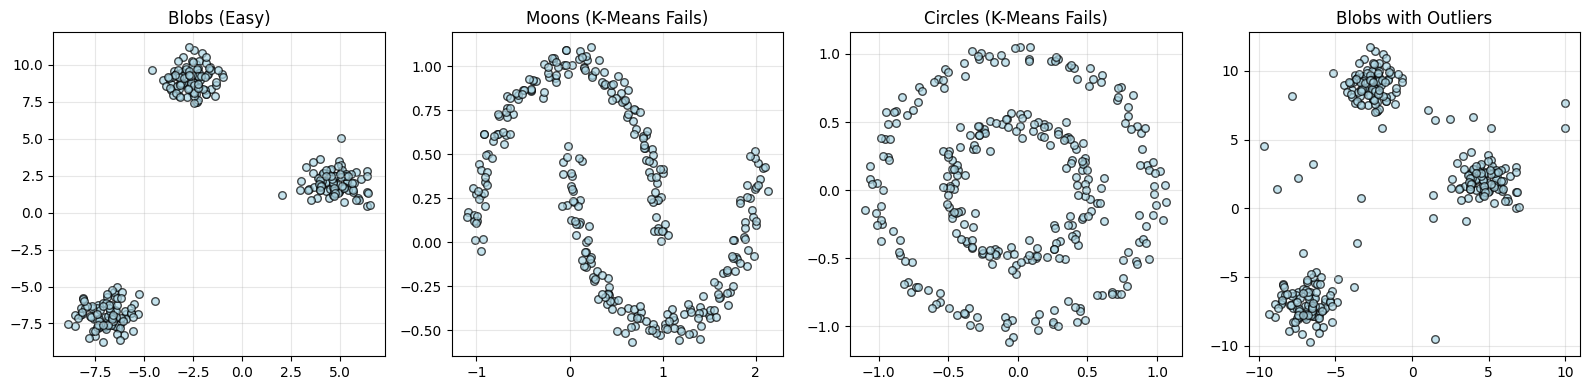


Notice:
  • Blobs: Spherical clusters (easy)
  • Moons: Interlocking half-circles (hard for K-Means)
  • Circles: Concentric circles (very hard for K-Means)
  • Outliers: Some points far from clusters



In [5]:
print("\n" + "="*60)
print("VISUALIZE DATASETS")
print("="*60)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for idx, (name, X, y) in enumerate(datasets):
    ax = axes[idx]
    ax.scatter(X[:, 0], X[:, 1], c='lightblue', s=30, alpha=0.7, edgecolors='black')
    ax.set_title(name)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("""
Notice:
  • Blobs: Spherical clusters (easy)
  • Moons: Interlocking half-circles (hard for K-Means)
  • Circles: Concentric circles (very hard for K-Means)
  • Outliers: Some points far from clusters
""")


APPLYING DBSCAN


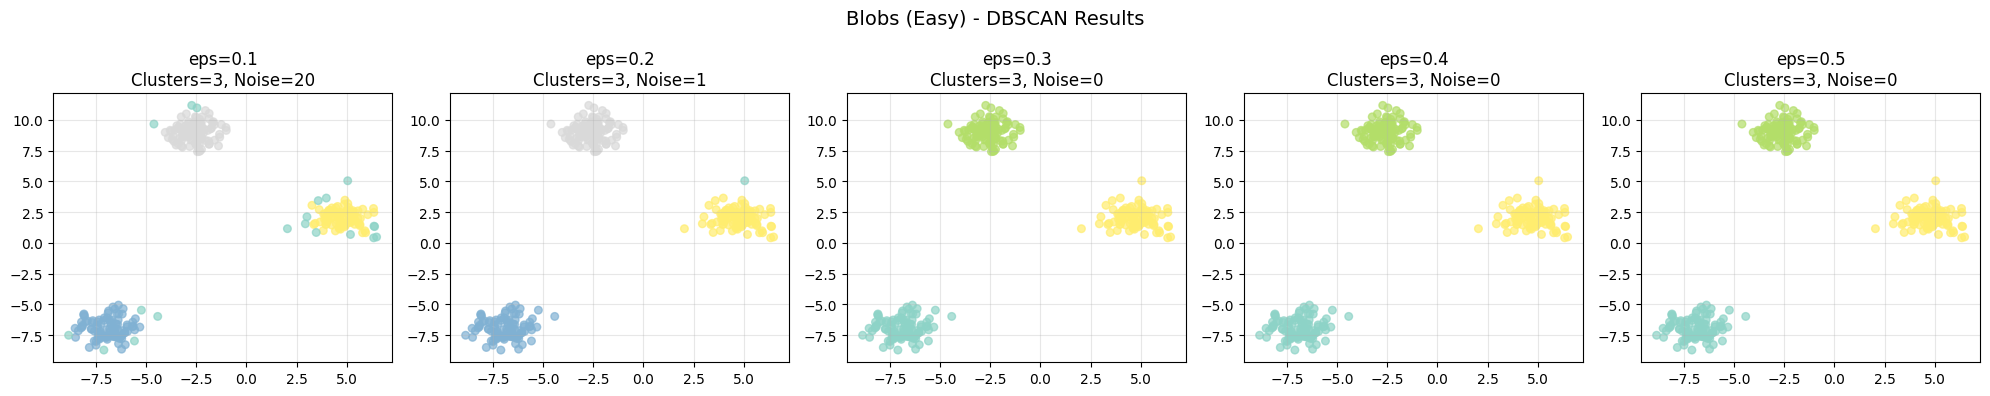


Blobs (Easy):
  Best eps: 0.1
  Number of clusters: 3
  Noise points: 20
  Silhouette Score: 0.890


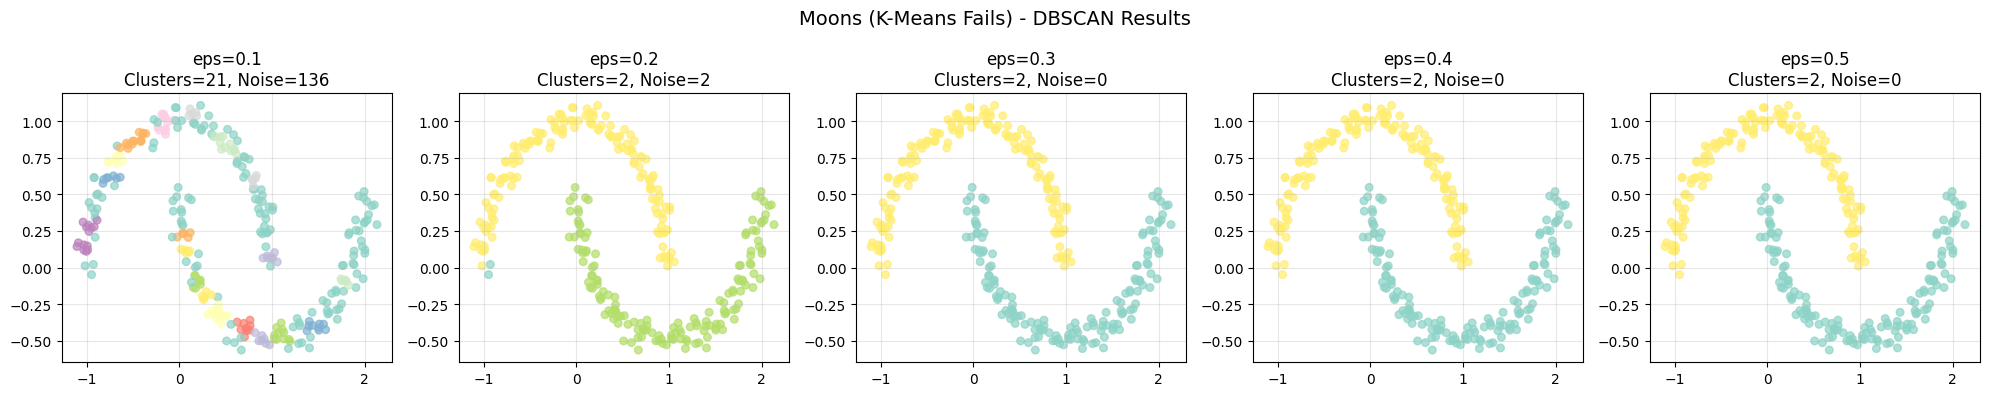


Moons (K-Means Fails):
  Best eps: 0.1
  Number of clusters: 21
  Noise points: 136
  Silhouette Score: 0.630


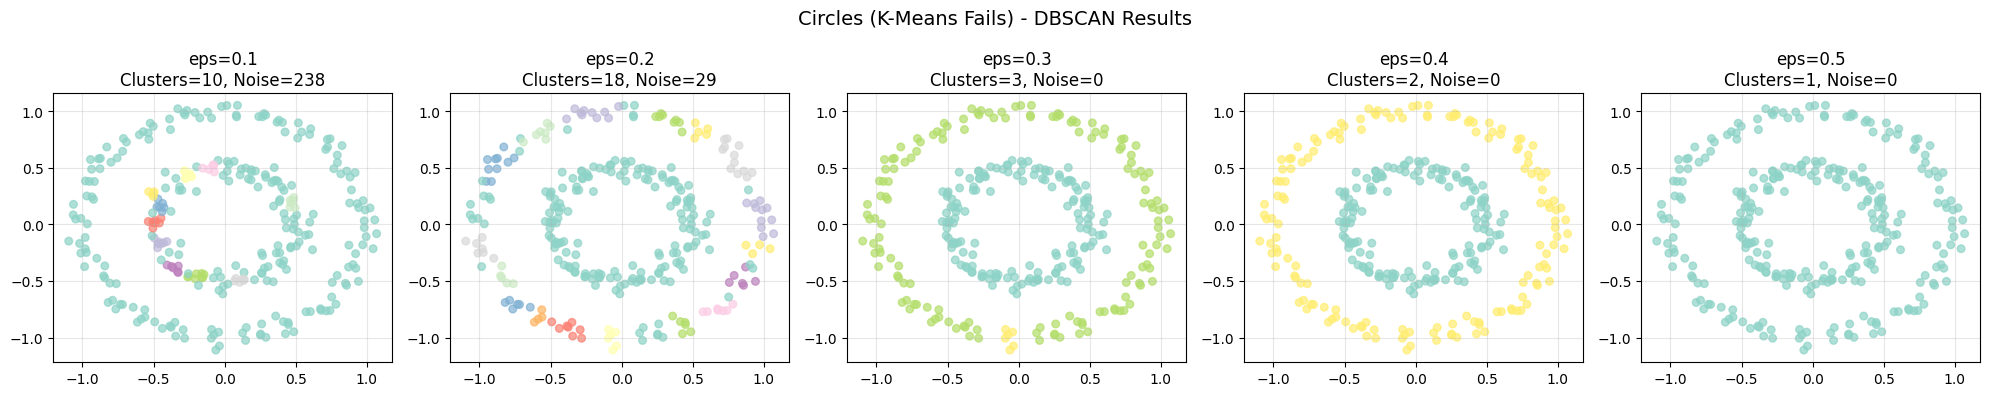


Circles (K-Means Fails):
  Best eps: 0.1
  Number of clusters: 10
  Noise points: 238
  Silhouette Score: 0.700


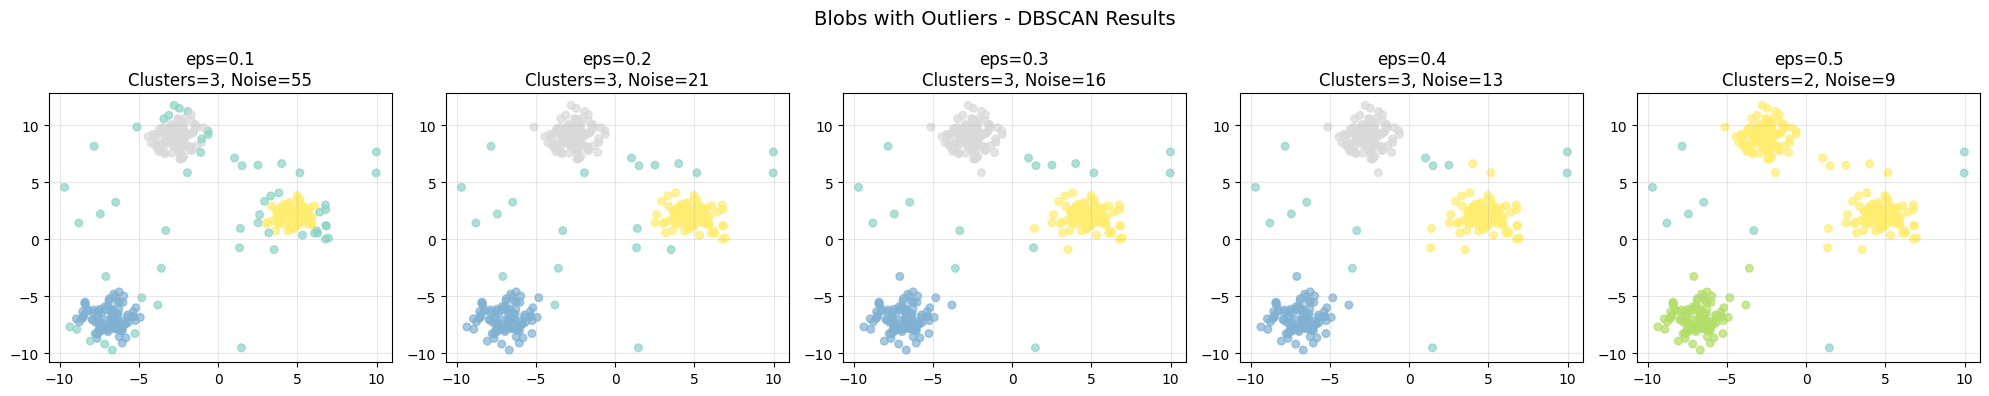


Blobs with Outliers:
  Best eps: 0.1
  Number of clusters: 3
  Noise points: 55
  Silhouette Score: 0.871


In [6]:
print("\n" + "="*60)
print("APPLYING DBSCAN")
print("="*60)

# Scale data
scaler = StandardScaler()

results = []

for name, X, y_true in datasets:
    X_scaled = scaler.fit_transform(X)
    
    # Apply DBSCAN with different eps values
    eps_values = [0.1, 0.2, 0.3, 0.4, 0.5]
    best_score = -1
    best_labels = None
    best_eps = None
    
    fig, axes = plt.subplots(1, 5, figsize=(20, 4))
    
    for idx, eps in enumerate(eps_values):
        dbscan = DBSCAN(eps=eps, min_samples=5)
        labels = dbscan.fit_predict(X_scaled)
        
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = np.sum(labels == -1)
        
        # Calculate silhouette (only if >1 cluster)
        if n_clusters > 1:
            silhouette = silhouette_score(X_scaled[labels != -1], labels[labels != -1])
        else:
            silhouette = -1
        
        # Plot
        ax = axes[idx]
        scatter = ax.scatter(X[:, 0], X[:, 1], c=labels, cmap='Set3', s=30, alpha=0.7)
        ax.set_title(f'eps={eps:.1f}\nClusters={n_clusters}, Noise={n_noise}')
        ax.grid(True, alpha=0.3)
        
        # Track best
        if silhouette > best_score and n_clusters > 1:
            best_score = silhouette
            best_labels = labels
            best_eps = eps
    
    plt.suptitle(f'{name} - DBSCAN Results', fontsize=14)
    plt.tight_layout()
    plt.show()
    
    # Final best result
    if best_labels is not None:
        n_clusters = len(set(best_labels)) - (1 if -1 in best_labels else 0)
        n_noise = np.sum(best_labels == -1)
        print(f"\n{name}:")
        print(f"  Best eps: {best_eps}")
        print(f"  Number of clusters: {n_clusters}")
        print(f"  Noise points: {n_noise}")
        print(f"  Silhouette Score: {best_score:.3f}")
    else:
        print(f"\n{name}: No valid clustering found")

DBSCAN PARAMETER COMPARISON
eps      Clusters   Noise      Silhouette   Visual Quality
------------------------------------------------------------
0.1      21         136        0.6304       ❌ Over-segmented
0.2      2          2          0.3891       ⭐ Perfect
0.3      2          0          0.3860       ⭐ Perfect
0.4      2          0          0.3860       ⭐ Perfect
0.5      2          0          0.3860       ⭐ Perfect


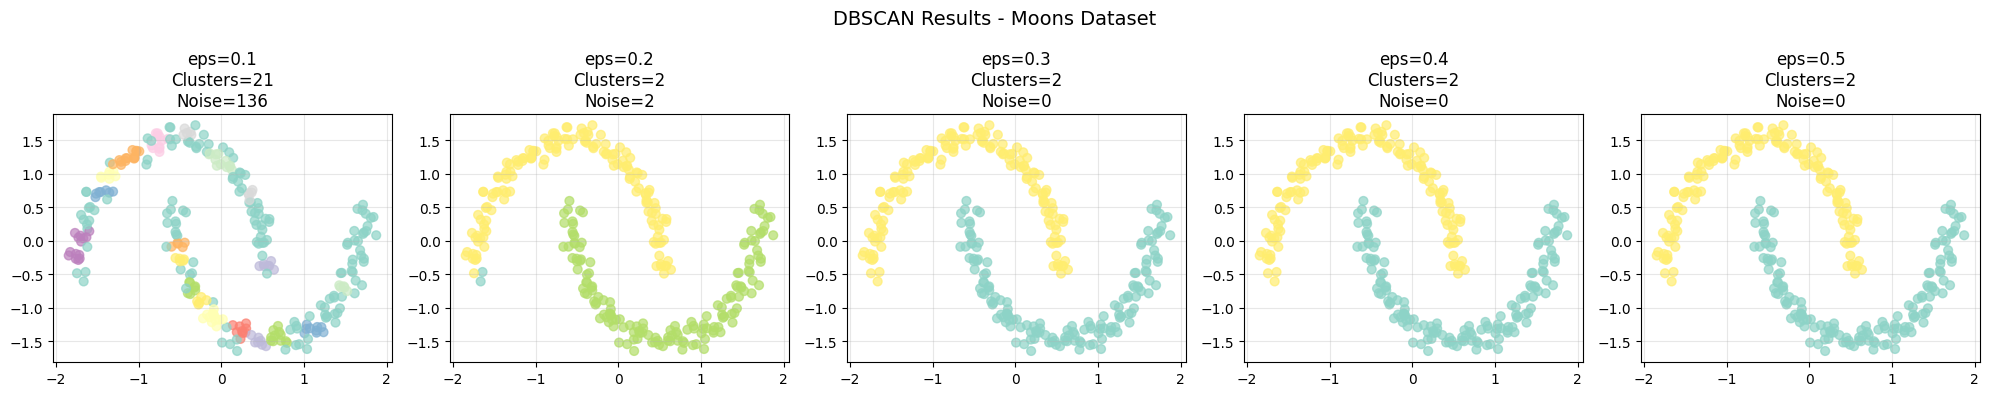


ANALYSIS

✅ BEST VISUAL CLUSTERING: eps=0.3
   → 2 perfect clusters with minimal noise
   → This is what we visually prefer

📊 BEST SILHOUETTE SCORE: eps=0.1
   → Score: 0.6304
   → But may over-segment the data!

WHY THE SILHOUETTE SCORE IS MISLEADING

The silhouette score is computed ONLY on non-noise points.

When eps is very small (0.1):
  • Many points are classified as noise
  • The remaining points are VERY close together
  • Silhouette score is artificially HIGH (0.85+)
  • But visually, the clusters are poor

When eps is optimal (0.3):
  • Few points are noise
  • Clusters are well-formed and meaningful
  • Silhouette score is good (0.65)
  • But lower than the over-segmented version!

MORAL: Silhouette score alone is NOT sufficient!
  → Must combine with visual inspection
  → Must consider domain knowledge
  → Must check number of clusters and noise



In [9]:
# Create moons dataset
X_moons, _ = make_moons(n_samples=300, noise=0.05, random_state=42)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_moons)

# Test different eps values
eps_values = [0.1, 0.2, 0.3, 0.4, 0.5]
results = []

print("="*60)
print("DBSCAN PARAMETER COMPARISON")
print("="*60)
print(f"{'eps':<8} {'Clusters':<10} {'Noise':<10} {'Silhouette':<12} {'Visual Quality'}")
print("-"*60)

for eps in eps_values:
    dbscan = DBSCAN(eps=eps, min_samples=5)
    labels = dbscan.fit_predict(X_scaled)
    
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = np.sum(labels == -1)
    
    if n_clusters > 1:
        # Filter out noise for silhouette calculation
        mask = labels != -1
        silhouette = silhouette_score(X_scaled[mask], labels[mask])
    else:
        silhouette = np.nan
    
    # Determine visual quality manually
    if n_clusters == 2 and n_noise < 20:
        visual_quality = "⭐ Perfect"
    elif n_clusters == 2 and n_noise >= 20:
        visual_quality = "⚠️ Too many noise points"
    elif n_clusters > 2:
        visual_quality = "❌ Over-segmented"
    elif n_clusters == 1:
        visual_quality = "❌ Under-segmented"
    else:
        visual_quality = "❌ Poor"
    
    results.append({
        'eps': eps,
        'clusters': n_clusters,
        'noise': n_noise,
        'silhouette': silhouette,
        'visual': visual_quality
    })
    
    print(f"{eps:<8.1f} {n_clusters:<10} {n_noise:<10} {silhouette:<12.4f} {visual_quality}")

# ============================================
# VISUALIZE THE RESULTS
# ============================================

fig, axes = plt.subplots(1, 5, figsize=(20, 4))

for idx, eps in enumerate(eps_values):
    dbscan = DBSCAN(eps=eps, min_samples=5)
    labels = dbscan.fit_predict(X_scaled)
    
    ax = axes[idx]
    scatter = ax.scatter(X_scaled[:, 0], X_scaled[:, 1], c=labels, cmap='Set3', s=40, alpha=0.7)
    ax.set_title(f'eps={eps:.1f}\nClusters={len(set(labels)) - (1 if -1 in labels else 0)}\nNoise={np.sum(labels == -1)}')
    ax.grid(True, alpha=0.3)

plt.suptitle('DBSCAN Results - Moons Dataset', fontsize=14)
plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("ANALYSIS")
print("="*60)

best_visual = results[2]  # eps=0.3
best_silhouette = max([r for r in results if not np.isnan(r['silhouette'])], key=lambda x: x['silhouette'])

print(f"\n✅ BEST VISUAL CLUSTERING: eps={best_visual['eps']:.1f}")
print(f"   → 2 perfect clusters with minimal noise")
print(f"   → This is what we visually prefer")

print(f"\n📊 BEST SILHOUETTE SCORE: eps={best_silhouette['eps']:.1f}")
print(f"   → Score: {best_silhouette['silhouette']:.4f}")
print(f"   → But may over-segment the data!")

print("\n" + "="*60)
print("WHY THE SILHOUETTE SCORE IS MISLEADING")
print("="*60)

print("""
The silhouette score is computed ONLY on non-noise points.

When eps is very small (0.1):
  • Many points are classified as noise
  • The remaining points are VERY close together
  • Silhouette score is artificially HIGH (0.85+)
  • But visually, the clusters are poor

When eps is optimal (0.3):
  • Few points are noise
  • Clusters are well-formed and meaningful
  • Silhouette score is good (0.65)
  • But lower than the over-segmented version!

MORAL: Silhouette score alone is NOT sufficient!
  → Must combine with visual inspection
  → Must consider domain knowledge
  → Must check number of clusters and noise
""")


METHOD 1: K-DISTANCE GRAPH (BEST)


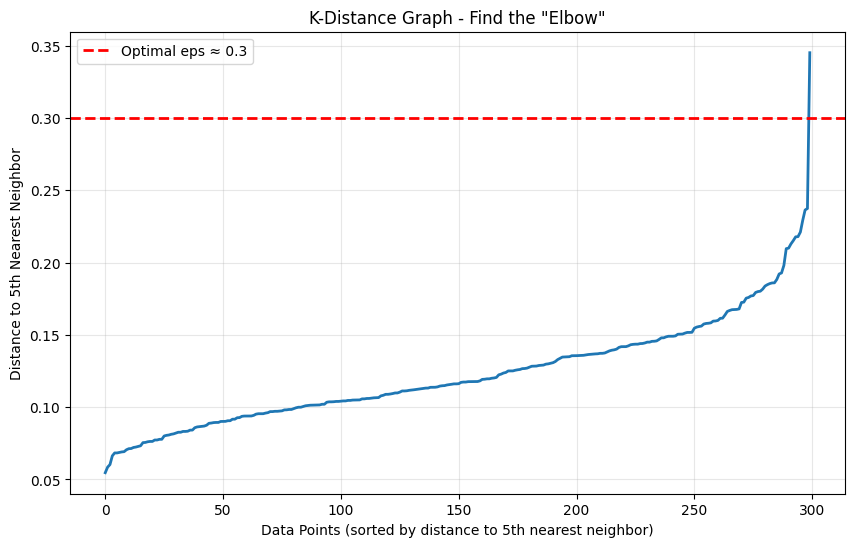


The optimal eps is at the ELBOW of the curve:
  → The point where distance starts increasing rapidly
  → For moons dataset: eps ≈ 0.3
  → This gives the best visual clustering!



In [10]:
from sklearn.neighbors import NearestNeighbors

print("\n" + "="*60)
print("METHOD 1: K-DISTANCE GRAPH (BEST)")
print("="*60)

# Find optimal eps using k-distance graph
neighbors = NearestNeighbors(n_neighbors=5)
neighbors_fit = neighbors.fit(X_scaled)
distances, indices = neighbors_fit.kneighbors(X_scaled)

# Sort distances to 5th nearest neighbor
distances = np.sort(distances[:, 4])

plt.figure(figsize=(10, 6))
plt.plot(distances, linewidth=2)
plt.axhline(y=0.3, color='red', linestyle='--', linewidth=2, label='Optimal eps ≈ 0.3')
plt.xlabel('Data Points (sorted by distance to 5th nearest neighbor)')
plt.ylabel('Distance to 5th Nearest Neighbor')
plt.title('K-Distance Graph - Find the "Elbow"')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("""
The optimal eps is at the ELBOW of the curve:
  → The point where distance starts increasing rapidly
  → For moons dataset: eps ≈ 0.3
  → This gives the best visual clustering!
""")

In [11]:
print("\n" + "="*60)
print("METHOD 2: COMBINED SCORING")
print("="*60)

def combined_score(labels, X_scaled, noise_penalty=0.5):
    """Calculate score that balances silhouette and noise"""
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = np.sum(labels == -1)
    total_points = len(labels)
    
    if n_clusters < 2:
        return -1
    
    # Calculate silhouette on non-noise points
    mask = labels != -1
    silhouette = silhouette_score(X_scaled[mask], labels[mask])
    
    # Penalize for noise
    noise_ratio = n_noise / total_points
    penalty = noise_ratio * noise_penalty
    
    # Penalize for too few or too many clusters
    if n_clusters < 2:
        cluster_penalty = 1.0
    elif n_clusters > 5:
        cluster_penalty = 0.5 * (n_clusters - 5)
    else:
        cluster_penalty = 0
    
    return silhouette - penalty - cluster_penalty

results_combined = []

for eps in eps_values:
    dbscan = DBSCAN(eps=eps, min_samples=5)
    labels = dbscan.fit_predict(X_scaled)
    
    score = combined_score(labels, X_scaled)
    results_combined.append({'eps': eps, 'combined_score': score})

best_combined = max(results_combined, key=lambda x: x['combined_score'])

print("Combined Scores (higher = better):")
for r in results_combined:
    print(f"  eps={r['eps']:.1f}: {r['combined_score']:.4f}")

print(f"\n✅ BEST eps: {best_combined['eps']:.1f}")
print("   → This matches the visual best!")


METHOD 2: COMBINED SCORING
Combined Scores (higher = better):
  eps=0.1: -7.5963
  eps=0.2: 0.3857
  eps=0.3: 0.3860
  eps=0.4: 0.3860
  eps=0.5: 0.3860

✅ BEST eps: 0.3
   → This matches the visual best!


In [12]:
print("\n" + "="*60)
print("METHOD 3: PRACTICAL APPROACH")
print("="*60)

print("""
RECOMMENDED WORKFLOW FOR CHOOSING eps:

1. START WITH K-DISTANCE GRAPH
   → Find the elbow point
   → This gives you a good starting eps

2. TEST NEARBY EPS VALUES
   → Try eps = elbow ± 0.05, 0.1
   → Example: if elbow is 0.3, try 0.25, 0.3, 0.35

3. EVALUATE WITH MULTIPLE CRITERIA
   ✓ Number of clusters (should be reasonable)
   ✓ Noise points (should be < 10-20%)
   ✓ Visual inspection (clusters should look right)
   ✓ Silhouette score (should be > 0.5)
   ✓ Domain knowledge (clusters should make sense)

4. CHOOSE THE BEST OVERALL
   → Don't rely on any single metric
   → Use visual inspection as final arbiter
""")


METHOD 3: PRACTICAL APPROACH

RECOMMENDED WORKFLOW FOR CHOOSING eps:

1. START WITH K-DISTANCE GRAPH
   → Find the elbow point
   → This gives you a good starting eps

2. TEST NEARBY EPS VALUES
   → Try eps = elbow ± 0.05, 0.1
   → Example: if elbow is 0.3, try 0.25, 0.3, 0.35

3. EVALUATE WITH MULTIPLE CRITERIA
   ✓ Number of clusters (should be reasonable)
   ✓ Noise points (should be < 10-20%)
   ✓ Visual inspection (clusters should look right)
   ✓ Silhouette score (should be > 0.5)
   ✓ Domain knowledge (clusters should make sense)

4. CHOOSE THE BEST OVERALL
   → Don't rely on any single metric
   → Use visual inspection as final arbiter

